# Skenario 3 & 4: Multimodal Fusion (S3 & S4)

| | S3 | S4 |
|---|---|---|
| **Input** | Tabular + Gambar | Tabular + Gambar |
| **Output** | Biner (Normal/Abnormal) | Multi-label (14 penyakit) |
| **Loss** | BCEWithLogitsLoss (1 output) | BCEWithLogitsLoss (14 output, weighted) |
| **Metrik** | Accuracy, F1, AUC-ROC | mAP, Macro AUC-ROC |

**Arsitektur:** Intermediate Fusion — TabularBranch (MLP) + ImageBranch (DenseNet-121) → Concatenate → Fusion Head  
Model diambil dari `src/models/architectures.py` kelas `MultimodalFusion`.

In [1]:
import sys
sys.path.insert(0, r"D:\TA\nih-multimodal")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, roc_curve, accuracy_score,
    average_precision_score
)

from configs.config import cfg
from src.models.architectures import MultimodalFusion
from src.data.dataset import create_dataloaders, compute_pos_weights

torch.manual_seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR   = cfg.paths.figures_dir
CKPT_DIR   = cfg.paths.checkpoint_dir
TABLES_DIR = cfg.paths.project_root / "results" / "tables"
for d in [SAVE_DIR, CKPT_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = list(cfg.data.label_names)
ACCUM_STEPS = cfg.train.gradient_accumulation_steps

print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Labels  : {len(LABEL_NAMES)} penyakit")

Device  : cuda
GPU     : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM    : 6.4 GB
Labels  : 14 penyakit


## 1. Load Dataset

In [2]:
train_loader, val_loader, test_loader, scaler, pos_weights_multilabel = create_dataloaders(
    batch_size=cfg.train.batch_size
)
pos_weights_multilabel = pos_weights_multilabel.to(DEVICE)

# pos_weight untuk binary (S3)
y_binary_train = np.concatenate([b["label_binary"].numpy() for b in train_loader])
pos_ratio = y_binary_train.mean()
pw_binary = torch.tensor([(1 - pos_ratio) / pos_ratio], dtype=torch.float32).to(DEVICE)

print(f"Train : {len(train_loader.dataset):,} | Val : {len(val_loader.dataset):,} | Test : {len(test_loader.dataset):,}")
print(f"Binary pos_weight : {pw_binary.item():.3f}")
print(f"Multilabel pos_weights (14): min={pos_weights_multilabel.min():.2f}, max={pos_weights_multilabel.max():.2f}")

[Data] Indexed 112120 images across 12 directories
[Data] Loaded metadata: 112120 samples, 30805 patients
[Data] Split — Train: 77994 | Val: 8530 | Test: 25596
Train : 77,994 | Val : 8,530 | Test : 25,596
Binary pos_weight : 1.400
Multilabel pos_weights (14): min=2.29, max=25.26


---
# Skenario 3: Multimodal Fusion — Klasifikasi Biner

## 2. Model S3

In [3]:
model_s3 = MultimodalFusion(num_classes=1).to(DEVICE)
criterion_s3 = nn.BCEWithLogitsLoss(pos_weight=pw_binary)
scaler_amp_s3 = GradScaler('cuda', enabled=cfg.train.use_amp)

optimizer_s3 = torch.optim.AdamW([
    {"params": model_s3.tabular_branch.parameters(), "lr": cfg.train.lr_tabular},
    {"params": model_s3.image_branch.parameters(),   "lr": cfg.train.lr_backbone},
    {"params": model_s3.fusion.parameters(),         "lr": cfg.train.lr_fusion},
    {"params": model_s3.classifier.parameters(),     "lr": cfg.train.lr_fusion},
], weight_decay=cfg.train.weight_decay)

scheduler_s3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s3, mode="max", patience=cfg.train.scheduler_patience,
    factor=cfg.train.scheduler_factor, verbose=True
)

total = sum(p.numel() for p in model_s3.parameters())
trainable = sum(p.numel() for p in model_s3.parameters() if p.requires_grad)
print(f"MultimodalFusion S3 | Total: {total:,} | Trainable: {trainable:,}")

MultimodalFusion S3 | Total: 7,703,105 | Trainable: 2,805,153


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 3. Training Loop S3

In [4]:
def train_epoch_mm(model, loader, criterion, optimizer, scaler_amp, device,
                   accum_steps, label_key="label_binary"):
    model.train()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader):
        images  = batch["image"].to(device, non_blocking=True)
        tabular = batch["tabular"].to(device, non_blocking=True)
        labels  = batch[label_key].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images, tabular=tabular)
            if label_key == "label_binary":
                logits = logits.squeeze(1)
            loss = criterion(logits, labels) / accum_steps

        scaler_amp.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * accum_steps * len(labels)
        n += len(labels)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    if label_key == "label_binary":
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = roc_auc_score(all_labels, all_probs, average="macro")
    return total_loss / n, auc


@torch.no_grad()
def evaluate_mm(model, loader, criterion, device, label_key="label_binary"):
    model.eval()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []

    for batch in loader:
        images  = batch["image"].to(device, non_blocking=True)
        tabular = batch["tabular"].to(device, non_blocking=True)
        labels  = batch[label_key].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images, tabular=tabular)
            if label_key == "label_binary":
                logits = logits.squeeze(1)
            loss = criterion(logits, labels)

        total_loss += loss.item() * len(labels)
        n += len(labels)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    if label_key == "label_binary":
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = roc_auc_score(all_labels, all_probs, average="macro")
    return total_loss / n, auc, all_probs, all_labels


# ── Training S3 ──
CKPT_S3  = CKPT_DIR / "model_s3_multimodal_binary.pt"
history_s3 = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_val_auc_s3, patience_counter = 0.0, 0
t0 = time.time()

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train AUC':>10} {'Val Loss':>10} {'Val AUC':>9} {'Time':>7}")
print("-" * 60)

for epoch in range(1, cfg.train.num_epochs + 1):
    ep_start = time.time()
    train_loss, train_auc = train_epoch_mm(
        model_s3, train_loader, criterion_s3, optimizer_s3,
        scaler_amp_s3, DEVICE, ACCUM_STEPS, label_key="label_binary"
    )
    val_loss, val_auc, _, _ = evaluate_mm(
        model_s3, val_loader, criterion_s3, DEVICE, label_key="label_binary"
    )
    history_s3["train_loss"].append(train_loss)
    history_s3["val_loss"].append(val_loss)
    history_s3["train_auc"].append(train_auc)
    history_s3["val_auc"].append(val_auc)
    scheduler_s3.step(val_auc)
    ep_time = time.time() - ep_start

    flag = ""
    if val_auc > best_val_auc_s3:
        best_val_auc_s3 = val_auc
        torch.save(model_s3.state_dict(), CKPT_S3)
        patience_counter = 0
        flag = " ✓"
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>12.4f} {train_auc:>10.4f} "
          f"{val_loss:>10.4f} {val_auc:>9.4f} {ep_time:>6.1f}s{flag}")

    if patience_counter >= cfg.train.early_stop_patience:
        print(f"\nEarly stopping di epoch {epoch}")
        break

print(f"\nS3 selesai {(time.time()-t0)/60:.1f} menit | Best Val AUC: {best_val_auc_s3:.4f}")

Epoch   Train Loss  Train AUC   Val Loss   Val AUC    Time
------------------------------------------------------------
    1       0.7366     0.7019     0.7055    0.7370  680.3s ✓
    2       0.7171     0.7246     0.7013    0.7427  675.9s ✓
    3       0.7103     0.7313     0.6972    0.7475  681.9s ✓
    4       0.7065     0.7359     0.6959    0.7503  672.2s ✓
    5       0.7036     0.7391     0.7084    0.7440  670.4s
    6       0.7004     0.7421     0.6970    0.7478  668.7s
    7       0.6975     0.7451     0.6942    0.7487  664.4s
    8       0.6964     0.7462     0.6901    0.7513  664.0s ✓
    9       0.6929     0.7499     0.6926    0.7522  661.5s ✓
   10       0.6901     0.7525     0.7120    0.7495  658.3s
   11       0.6890     0.7537     0.6913    0.7517  708.6s
   12       0.6864     0.7565     0.6929    0.7513  698.1s
   13       0.6846     0.7579     0.6933    0.7492  680.1s
   14       0.6771     0.7644     0.7082    0.7489  656.0s
   15       0.6747     0.7670     0.6945  

## 4. Evaluasi S3

In [5]:
model_s3.load_state_dict(torch.load(CKPT_S3, map_location=DEVICE))
_, _, test_probs_s3, test_labels_s3 = evaluate_mm(
    model_s3, test_loader, criterion_s3, DEVICE, label_key="label_binary"
)
test_preds_s3 = (test_probs_s3 >= 0.5).astype(int)

acc_s3  = accuracy_score(test_labels_s3, test_preds_s3)
f1_s3   = f1_score(test_labels_s3, test_preds_s3, average="binary")
f1m_s3  = f1_score(test_labels_s3, test_preds_s3, average="macro")
auc_s3  = roc_auc_score(test_labels_s3, test_probs_s3)

print("=" * 55)
print("HASIL EVALUASI SKENARIO 3: MULTIMODAL FUSION BINER")
print("=" * 55)
print(f"Accuracy       : {acc_s3:.4f}")
print(f"F1-Score (bin) : {f1_s3:.4f}")
print(f"F1-Score (mac) : {f1m_s3:.4f}")
print(f"AUC-ROC        : {auc_s3:.4f}")
print()
print(classification_report(test_labels_s3, test_preds_s3, target_names=["Normal", "Abnormal"]))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29920\945812135.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_s3.load_state_dict(torch.load(CKPT_S3, map_location=DEVI

HASIL EVALUASI SKENARIO 3: MULTIMODAL FUSION BINER
Accuracy       : 0.6976
F1-Score (bin) : 0.7825
F1-Score (mac) : 0.6433
AUC-ROC        : 0.7050

              precision    recall  f1-score   support

      Normal       0.68      0.40      0.50      9861
    Abnormal       0.70      0.88      0.78     15735

    accuracy                           0.70     25596
   macro avg       0.69      0.64      0.64     25596
weighted avg       0.69      0.70      0.68     25596



## 5. ROC Curve S1 vs S2 vs S3

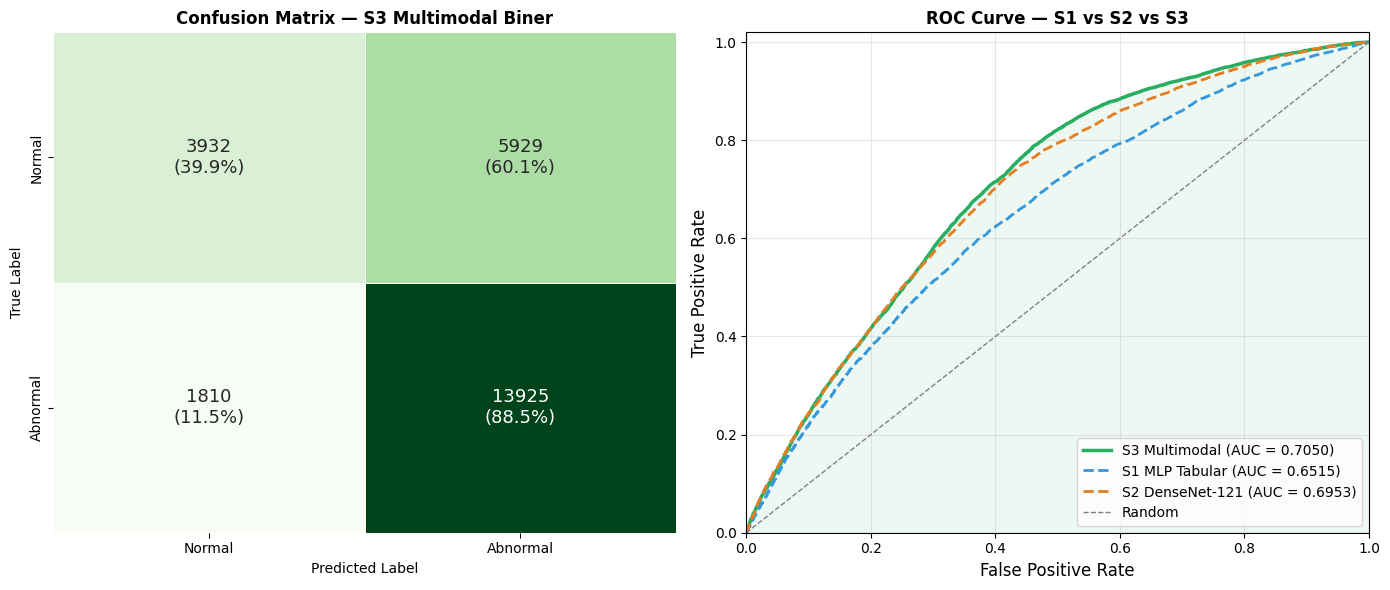

Disimpan → results/figures/s3_confusion_roc.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix S3
cm_s3  = confusion_matrix(test_labels_s3, test_preds_s3)
cm_pct = cm_s3.astype(float) / cm_s3.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f"{cm_s3[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm_s3, annot=annot, fmt="", cmap="Greens", ax=axes[0],
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"],
            linewidths=0.5, cbar=False, annot_kws={"size": 13})
axes[0].set_title("Confusion Matrix — S3 Multimodal Biner", fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC Curve perbandingan S1, S2, S3
fpr_s3, tpr_s3, _ = roc_curve(test_labels_s3, test_probs_s3)
axes[1].plot(fpr_s3, tpr_s3, color="#27ae60", linewidth=2.5,
             label=f"S3 Multimodal (AUC = {auc_s3:.4f})")

for fname, color, label in [
    ("predictions_s1.csv", "#3498db", "S1 MLP Tabular"),
    ("predictions_s2.csv", "#e67e22", "S2 DenseNet-121"),
]:
    p = TABLES_DIR / fname
    if p.exists():
        df_ = pd.read_csv(p)
        prob_col = [c for c in df_.columns if c.startswith("prob_")][0]
        fpr_, tpr_, _ = roc_curve(df_["true_label"], df_[prob_col])
        auc_ = roc_auc_score(df_["true_label"], df_[prob_col])
        axes[1].plot(fpr_, tpr_, color=color, linewidth=2, linestyle="--",
                     label=f"{label} (AUC = {auc_:.4f})")

axes[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random")
axes[1].fill_between(fpr_s3, tpr_s3, alpha=0.08, color="#27ae60")
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve — S1 vs S2 vs S3", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(SAVE_DIR / "s3_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "true_label": test_labels_s3.astype(int),
    "prob_s3"   : test_probs_s3,
    "pred_s3"   : test_preds_s3,
}).to_csv(TABLES_DIR / "predictions_s3.csv", index=False)
print("Disimpan → results/figures/s3_confusion_roc.png")

---
# Skenario 4: Multimodal Fusion — Klasifikasi Multi-label (14 Penyakit)

## 6. Model S4

In [7]:
# S4: num_classes=14, output layer = 14 sigmoid
model_s4 = MultimodalFusion(num_classes=14).to(DEVICE)

# Weighted BCE untuk setiap penyakit (sqrt-damped pos_weight)
criterion_s4  = nn.BCEWithLogitsLoss(pos_weight=pos_weights_multilabel)
scaler_amp_s4 = GradScaler('cuda', enabled=cfg.train.use_amp)

optimizer_s4 = torch.optim.AdamW([
    {"params": model_s4.tabular_branch.parameters(), "lr": cfg.train.lr_tabular},
    {"params": model_s4.image_branch.parameters(),   "lr": cfg.train.lr_backbone},
    {"params": model_s4.fusion.parameters(),         "lr": cfg.train.lr_fusion},
    {"params": model_s4.classifier.parameters(),     "lr": cfg.train.lr_fusion},
], weight_decay=cfg.train.weight_decay)

scheduler_s4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s4, mode="max", patience=cfg.train.scheduler_patience,
    factor=cfg.train.scheduler_factor, verbose=True
)
print(f"MultimodalFusion S4 | 14-label output")

MultimodalFusion S4 | 14-label output


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 7. Training Loop S4

In [8]:
CKPT_S4    = CKPT_DIR / "model_s4_multimodal_multilabel.pt"
history_s4 = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_val_auc_s4, patience_counter = 0.0, 0
t0 = time.time()

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train AUC':>10} {'Val Loss':>10} {'Val AUC':>9} {'Time':>7}")
print("-" * 60)

for epoch in range(1, cfg.train.num_epochs + 1):
    ep_start = time.time()
    train_loss, train_auc = train_epoch_mm(
        model_s4, train_loader, criterion_s4, optimizer_s4,
        scaler_amp_s4, DEVICE, ACCUM_STEPS, label_key="label_multilabel"
    )
    val_loss, val_auc, _, _ = evaluate_mm(
        model_s4, val_loader, criterion_s4, DEVICE, label_key="label_multilabel"
    )
    history_s4["train_loss"].append(train_loss)
    history_s4["val_loss"].append(val_loss)
    history_s4["train_auc"].append(train_auc)
    history_s4["val_auc"].append(val_auc)
    scheduler_s4.step(val_auc)
    ep_time = time.time() - ep_start

    flag = ""
    if val_auc > best_val_auc_s4:
        best_val_auc_s4 = val_auc
        torch.save(model_s4.state_dict(), CKPT_S4)
        patience_counter = 0
        flag = " ✓"
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>12.4f} {train_auc:>10.4f} "
          f"{val_loss:>10.4f} {val_auc:>9.4f} {ep_time:>6.1f}s{flag}")

    if patience_counter >= cfg.train.early_stop_patience:
        print(f"\nEarly stopping di epoch {epoch}")
        break

print(f"\nS4 selesai {(time.time()-t0)/60:.1f} menit | Best Val AUC: {best_val_auc_s4:.4f}")

Epoch   Train Loss  Train AUC   Val Loss   Val AUC    Time
------------------------------------------------------------
    1       0.4541     0.6788     0.4202    0.7480  678.0s ✓
    2       0.4253     0.7378     0.4100    0.7660  688.9s ✓
    3       0.4176     0.7504     0.4030    0.7743  686.3s ✓
    4       0.4113     0.7645     0.3997    0.7855  683.3s ✓
    5       0.4070     0.7710     0.3991    0.7803  683.8s
    6       0.4030     0.7774     0.3951    0.7862  688.4s ✓
    7       0.4007     0.7812     0.3929    0.7939  684.7s ✓
    8       0.3974     0.7853     0.3901    0.7957  687.5s ✓
    9       0.3933     0.7922     0.3878    0.7974  688.6s ✓
   10       0.3905     0.7972     0.3941    0.7928  690.3s
   11       0.3886     0.8005     0.3923    0.7955  688.2s
   12       0.3869     0.8025     0.3936    0.7895  670.9s
   13       0.3844     0.8057     0.3895    0.7965  689.7s
   14       0.3777     0.8141     0.3915    0.7952  699.5s
   15       0.3750     0.8187     0.39

## 8. Evaluasi S4 — Per-label AUC & mAP

In [9]:
model_s4.load_state_dict(torch.load(CKPT_S4, map_location=DEVICE))
_, _, test_probs_s4, test_labels_s4 = evaluate_mm(
    model_s4, test_loader, criterion_s4, DEVICE, label_key="label_multilabel"
)

# Per-label metrik
rows = []
for i, label in enumerate(LABEL_NAMES):
    if test_labels_s4[:, i].sum() > 0:  # skip label tanpa positif di test
        auc_i = roc_auc_score(test_labels_s4[:, i], test_probs_s4[:, i])
        ap_i  = average_precision_score(test_labels_s4[:, i], test_probs_s4[:, i])
    else:
        auc_i = ap_i = float("nan")
    rows.append({"Label": label, "AUC-ROC": round(auc_i, 4), "AP": round(ap_i, 4)})

df_per_label = pd.DataFrame(rows).sort_values("AUC-ROC", ascending=False)

macro_auc = roc_auc_score(test_labels_s4, test_probs_s4, average="macro")
mAP       = average_precision_score(test_labels_s4, test_probs_s4, average="macro")

print("=" * 50)
print("SKENARIO 4: MULTIMODAL FUSION MULTI-LABEL")
print("=" * 50)
print(df_per_label.to_string(index=False))
print(f"\nMacro AUC-ROC : {macro_auc:.4f}")
print(f"mAP (macro)   : {mAP:.4f}")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29920\752273428.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_s4.load_state_dict(torch.load(CKPT_S4, map_location=DEVI

SKENARIO 4: MULTIMODAL FUSION MULTI-LABEL
             Label  AUC-ROC     AP
            Hernia   0.8848 0.2444
         Emphysema   0.8596 0.2756
      Pneumothorax   0.8378 0.3708
             Edema   0.8288 0.1525
      Cardiomegaly   0.8229 0.2655
          Effusion   0.7957 0.4612
          Fibrosis   0.7761 0.0578
Pleural_Thickening   0.7355 0.1120
       Atelectasis   0.7310 0.2758
              Mass   0.7231 0.2103
     Consolidation   0.7184 0.1360
      Infiltration   0.6920 0.3824
            Nodule   0.6870 0.1670
         Pneumonia   0.6783 0.0419

Macro AUC-ROC : 0.7694
mAP (macro)   : 0.2252


## 9. Visualisasi Per-label AUC (S4)

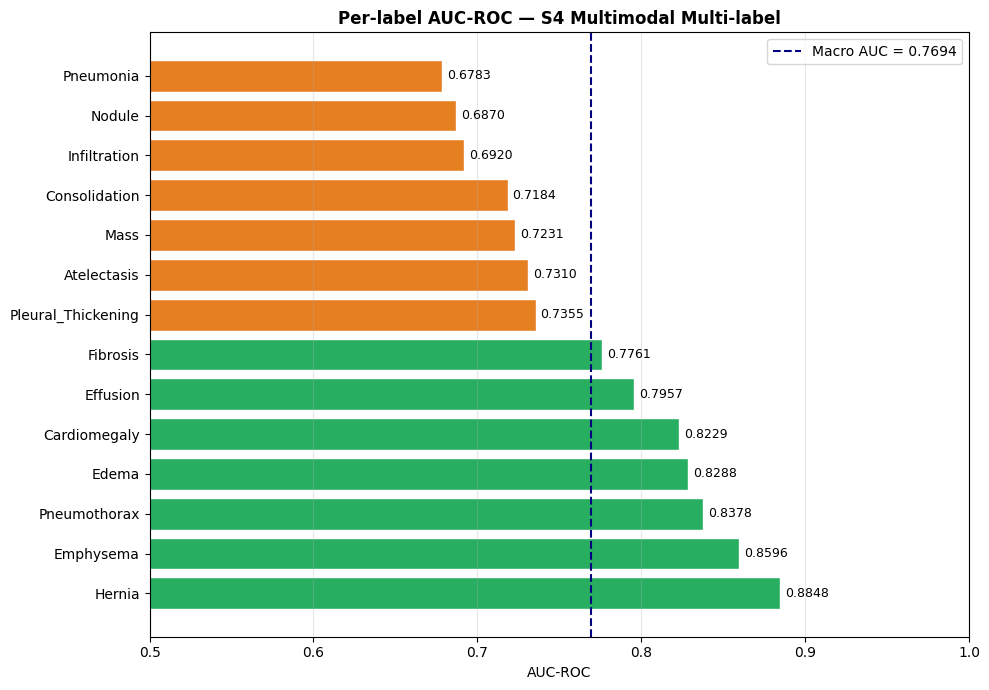

Disimpan → results/figures/s4_perlabel_auc.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#27ae60" if v >= 0.75 else "#e67e22" if v >= 0.65 else "#e74c3c"
          for v in df_per_label["AUC-ROC"]]
bars = ax.barh(df_per_label["Label"], df_per_label["AUC-ROC"], color=colors, edgecolor="white")
for bar, val in zip(bars, df_per_label["AUC-ROC"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.axvline(macro_auc, color="navy", linestyle="--", linewidth=1.5,
           label=f"Macro AUC = {macro_auc:.4f}")
ax.set_xlabel("AUC-ROC")
ax.set_title("Per-label AUC-ROC — S4 Multimodal Multi-label", fontweight="bold")
ax.set_xlim([0.5, 1.0])
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / "s4_perlabel_auc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/figures/s4_perlabel_auc.png")

## 10. Simpan Semua Hasil & Tabel Perbandingan S1–S4

In [11]:
# Simpan S3
pd.DataFrame([{
    "Skenario": "S3", "Model": "Multimodal Fusion",
    "Input": "Tabular + Gambar", "Output": "Biner",
    "Accuracy": round(acc_s3, 4), "F1 (Binary)": round(f1_s3, 4),
    "F1 (Macro)": round(f1m_s3, 4), "AUC-ROC": round(auc_s3, 4),
}]).to_csv(TABLES_DIR / "results_s3.csv", index=False)

# Simpan S4
pd.DataFrame([{
    "Skenario": "S4", "Model": "Multimodal Fusion",
    "Input": "Tabular + Gambar", "Output": "14 Label",
    "Macro AUC": round(macro_auc, 4), "mAP": round(mAP, 4),
}]).to_csv(TABLES_DIR / "results_s4.csv", index=False)
df_per_label.to_csv(TABLES_DIR / "results_s4_perlabel.csv", index=False)

# Simpan prediksi S4
df_pred_s4 = pd.DataFrame(
    test_probs_s4, columns=[f"prob_{l}" for l in LABEL_NAMES]
)
df_true_s4 = pd.DataFrame(
    test_labels_s4.astype(int), columns=[f"true_{l}" for l in LABEL_NAMES]
)
pd.concat([df_true_s4, df_pred_s4], axis=1).to_csv(
    TABLES_DIR / "predictions_s4.csv", index=False
)

# Tabel ringkasan S1–S3 (biner)
rows_summary = []
for f in ["results_s1.csv", "results_s2.csv", "results_s3.csv"]:
    p = TABLES_DIR / f
    if p.exists():
        rows_summary.append(pd.read_csv(p))
if rows_summary:
    df_summary = pd.concat(rows_summary, ignore_index=True)
    df_summary.to_csv(TABLES_DIR / "results_summary.csv", index=False)
    cols = [c for c in ["Skenario", "Model", "Accuracy", "F1 (Binary)", "F1 (Macro)", "AUC-ROC"] if c in df_summary.columns]
    print("\n=== PERBANDINGAN S1 vs S2 vs S3 ===")
    print(df_summary[cols].to_string(index=False))

print(f"\n=== SKENARIO 4 ===")
print(f"Macro AUC-ROC : {macro_auc:.4f}")
print(f"mAP (macro)   : {mAP:.4f}")
print("\nSemua hasil tersimpan di results/tables/")


=== PERBANDINGAN S1 vs S2 vs S3 ===
Skenario             Model  Accuracy  F1 (Binary)  F1 (Macro)  AUC-ROC
      S1       MLP Tabular    0.6040       0.6165      0.6036   0.6515
      S2      DenseNet-121    0.6808       0.7622      0.6384   0.6953
      S3 Multimodal Fusion    0.6976       0.7825      0.6433   0.7050

=== SKENARIO 4 ===
Macro AUC-ROC : 0.7694
mAP (macro)   : 0.2252

Semua hasil tersimpan di results/tables/


## 11. Learning Curves S3 & S4

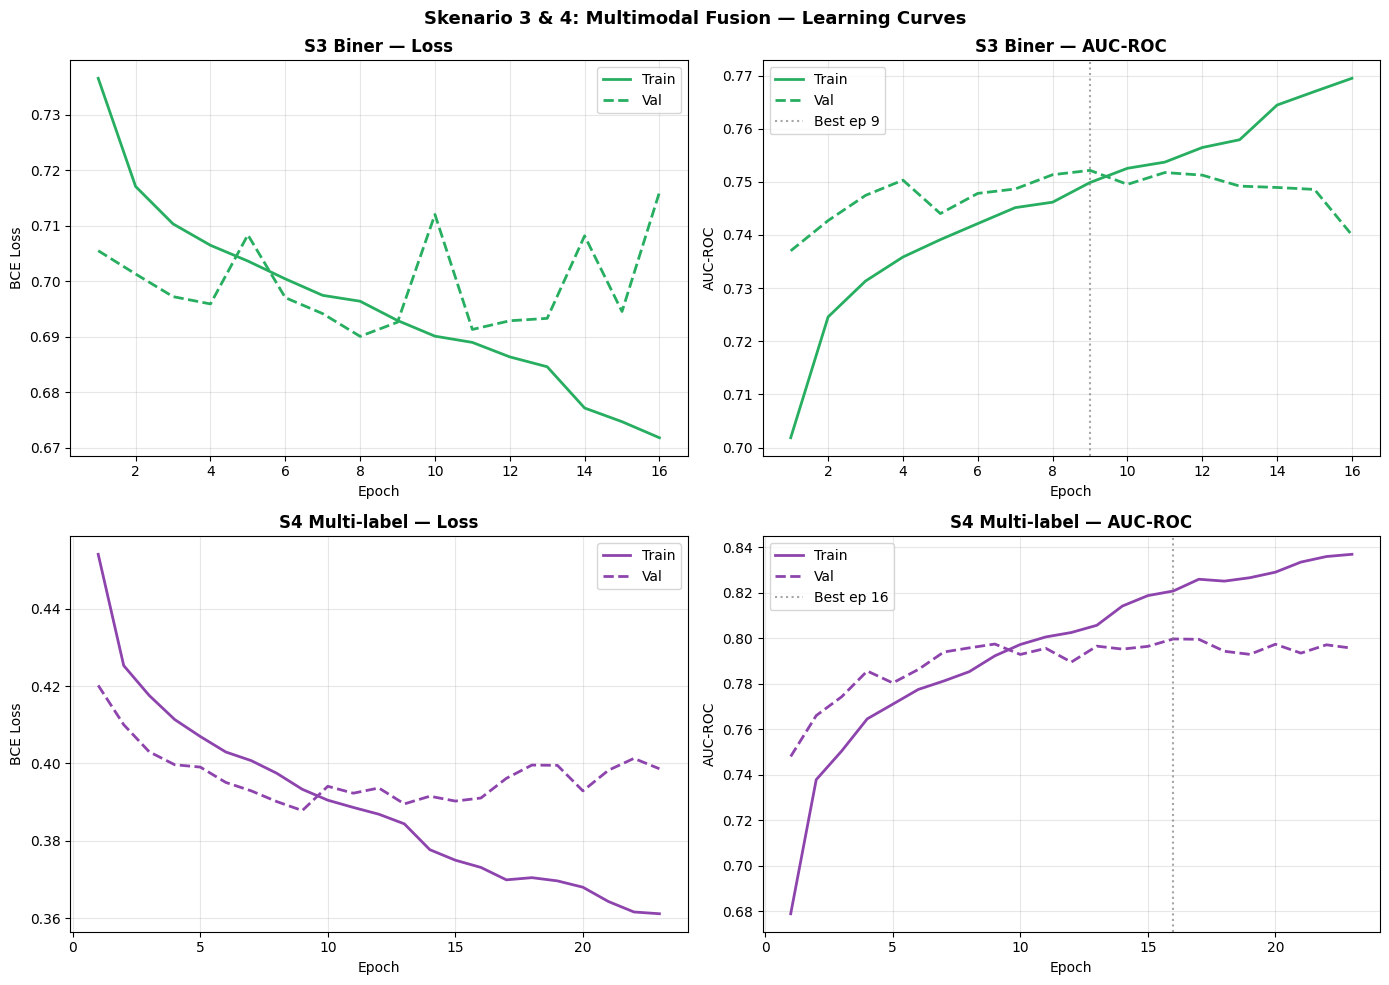

Disimpan → results/figures/s3s4_training_curves.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (hist, title, color) in enumerate([
    (history_s3, "S3 Biner",     "#27ae60"),
    (history_s4, "S4 Multi-label", "#8e44ad"),
]):
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[row, 0].plot(ep, hist["train_loss"], color=color, linewidth=2, label="Train")
    axes[row, 0].plot(ep, hist["val_loss"],   color=color, linewidth=2, linestyle="--", label="Val")
    axes[row, 0].set_title(f"{title} — Loss", fontweight="bold")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].set_ylabel("BCE Loss")
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(ep, hist["train_auc"], color=color, linewidth=2, label="Train")
    axes[row, 1].plot(ep, hist["val_auc"],   color=color, linewidth=2, linestyle="--", label="Val")
    best_ep = np.argmax(hist["val_auc"]) + 1
    axes[row, 1].axvline(best_ep, color="gray", linestyle=":", alpha=0.7, label=f"Best ep {best_ep}")
    axes[row, 1].set_title(f"{title} — AUC-ROC", fontweight="bold")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("AUC-ROC")
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

plt.suptitle("Skenario 3 & 4: Multimodal Fusion — Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "s3s4_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/figures/s3s4_training_curves.png")

## Ringkasan

**Artefak yang dihasilkan:**
- `results/checkpoints/model_s3_multimodal_binary.pt` — model S3 terbaik (untuk SHAP + Grad-CAM)
- `results/checkpoints/model_s4_multimodal_multilabel.pt` — model S4 terbaik
- `results/figures/s3_confusion_roc.png` — ROC perbandingan S1 vs S2 vs S3
- `results/figures/s4_perlabel_auc.png` — AUC per penyakit S4
- `results/figures/s3s4_training_curves.png` — learning curves
- `results/tables/results_summary.csv` — perbandingan S1–S3
- `results/tables/results_s4_perlabel.csv` — AUC & AP per penyakit S4
- `results/tables/predictions_s3.csv` & `predictions_s4.csv` — prediksi untuk XAI

> **Langkah selanjutnya:** Model terbaik (S3 atau S4) digunakan di Notebook 06 untuk analisis SHAP (branch tabular) dan Grad-CAM (branch gambar) secara simultan — ini adalah novelty utama penelitian ini.